# Performance Evaluation — Parallelism in Canny Edge Detection with cuTile
**Group 5 | SoftEng 751 2026**

This notebook is the single source of truth for performance analysis.
Every section: (1) states the parallelism **principle**, (2) validates it with **measured data**, (3) shows the **consequence** for this project.
No separate markdown report is generated — everything is explained inline.

In [1]:
import sys, csv, queue, threading, time
from pathlib import Path
from statistics import mean

import cv2
import cupy as cp
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

ROOT   = Path('..').resolve()
REPORT = ROOT / 'report'
sys.path.insert(0, str(ROOT / 'src' / 'gpu'))

from cutile_canny_pipeline_benchmark import (
    canny_pipeline_cpu,
    canny_pipeline_gpu_with_input_transfer,
)
from gaussian_benchmark import make_gaussian_kernel
from video_stream_demo import (
    double_threshold_and_hysteresis,
    frame_to_grayscale_float32,
    open_frame_source,
    read_next_frame,
    resize_frame,
    select_thresholds,
)

COLORS = dict(cpu='#E05252', gpu='#4C8BE0', cutile='#2BAE66',
              cupy='#F5A623', pipeline='#9B59B6', sequential='#E67E22')

def load_csv(name):
    p = REPORT / name
    if not p.exists():
        print(f'[warn] {p} not found'); return []
    with open(p, newline='') as f:
        return list(csv.DictReader(f))

def col(rows, key):
    return [float(r[key]) for r in rows]

KERNEL_CPU = make_gaussian_kernel(5, 1.4)
TILE_SIZE  = 256
print('Imports OK')

Imports OK


## 1. 像素级数据并行：三个阶段为什么可以完全并行化

Canny 前端（Gaussian → Sobel → NMS）每个输出像素**只依赖一个固定邻域的输入像素**，与同阶段任何其他输出像素无关。这一性质称为 **embarrassingly parallel**（完全数据并行）。

| 阶段 | 依赖关系 | 邻域大小 |
|------|----------|----------|
| Gaussian（水平 pass） | `out[r,c]` ← `in[r, c±radius]` | 1×k |
| Gaussian（垂直 pass） | `out[r,c]` ← `temp[r±radius, c]` | k×1 |
| Sobel | `out[r,c]` ← `blurred` 的 3×3 邻域 | 3×3 |
| NMS | `out[r,c]` ← `magnitude` 中心 + 2 个方向邻居 | 1+2 |

cuTile 把这种独立性直接映射为 GPU block：

```
N_blocks = ceil(pixels / tile_size)
每个 block 处理 tile_size 个像素，所有 block 同时运行在不同 GPU SM 上
```

下图展示 tile_size 如何决定并行粒度（block 数量）。

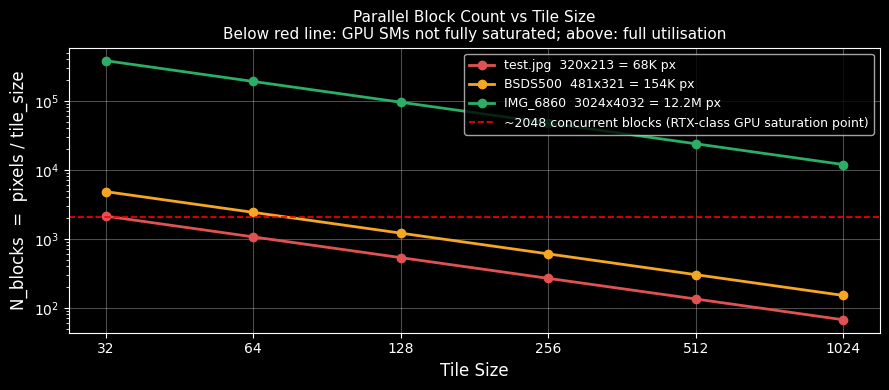

结论：对小图像（test.jpg, 68K px），tile=64 时 N_blocks=1063，GPU 基本饱和。
对大图像（IMG_6860, 12.2M px），任何 tile size 下 block 数都远超 2048，GPU 始终满载。
因此大图像 GPU 利用率更高，加速比也更大。


In [2]:
import math
fig, ax = plt.subplots(figsize=(9, 4))

tile_sizes = [32, 64, 128, 256, 512, 1024]
image_configs = [
    ('test.jpg  320x213 = 68K px',    320*213,        COLORS['cpu']),
    ('BSDS500  481x321 = 154K px',    481*321,        COLORS['cupy']),
    ('IMG_6860  3024x4032 = 12.2M px', 3024*4032,     COLORS['cutile']),
]
for label, pixels, color in image_configs:
    n_blocks = [math.ceil(pixels / ts) for ts in tile_sizes]
    ax.plot(tile_sizes, n_blocks, 'o-', label=label, color=color, linewidth=2)

ax.axhline(2048, color='red', linestyle='--', linewidth=1.2,
           label='~2048 concurrent blocks (RTX-class GPU saturation point)')
ax.set_xlabel('Tile Size', fontsize=12)
ax.set_ylabel('N_blocks  =  pixels / tile_size', fontsize=12)
ax.set_title('Parallel Block Count vs Tile Size\n'
             'Below red line: GPU SMs not fully saturated; above: full utilisation', fontsize=11)
ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.set_xticks(tile_sizes)
ax.set_xticklabels([str(t) for t in tile_sizes])
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('结论：对小图像（test.jpg, 68K px），tile=64 时 N_blocks=1063，GPU 基本饱和。')
print('对大图像（IMG_6860, 12.2M px），任何 tile size 下 block 数都远超 2048，GPU 始终满载。')
print('因此大图像 GPU 利用率更高，加速比也更大。')

## 2. Tile Size 是并行粒度的唯一可调参数

同一算法，`tile_size` 不同，性能差异可达 **3×**。原因：

- **tile_size 过小**（32–64 on small images）：block 数过多但每 block 计算量极少，kernel launch overhead 主导
- **tile_size 过大**（512+ on small images）：block 数太少，多数 SM 空闲；寄存器/共享内存压力也增大
- **中等 tile_size**（128–256）：launch overhead 与 SM 利用率最优平衡点

下图用实测的 cuTile Sobel kernel 验证这一模型。

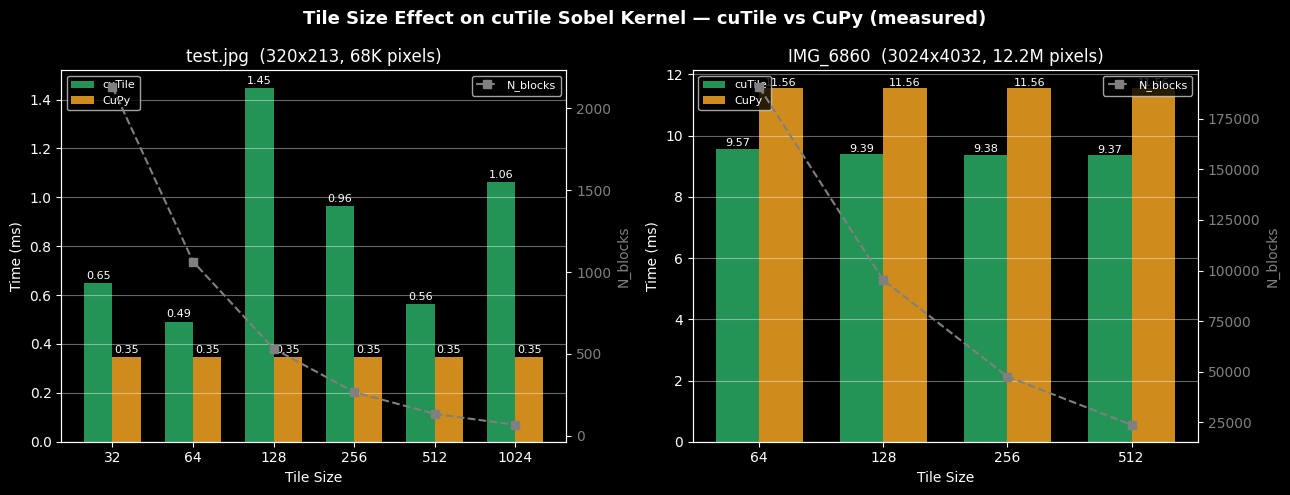

观察：N_blocks（灰线）随 tile_size 增大而减少。
对小图像，tile=64 最优（N_blocks 多，SM 充分利用，launch overhead 尚可接受）。
对大图像，N_blocks 在所有 tile size 下都充足，cuTile 在更大 tile 下融合操作更高效。


In [3]:
sobel_test = load_csv('17_sobel_cutile_tile_sweep_test.csv')
sobel_img  = load_csv('17_sobel_cutile_tile_sweep_IMG_6860.csv')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Tile Size Effect on cuTile Sobel Kernel — cuTile vs CuPy (measured)',
             fontsize=13, fontweight='bold')

for ax, rows, label, npx in [
    (axes[0], sobel_test, 'test.jpg  (320x213, 68K pixels)',   68160),
    (axes[1], sobel_img,  'IMG_6860  (3024x4032, 12.2M pixels)', 3024*4032),
]:
    if not rows:
        ax.set_title(label + ' — data missing'); continue
    ts    = [int(r['tile_size'])              for r in rows]
    ct_ms = [float(r['cutile_time_seconds'])*1000 for r in rows]
    cp_ms = [float(r['cupy_time_seconds'])*1000   for r in rows]
    x = np.arange(len(ts)); w = 0.35
    b1 = ax.bar(x-w/2, ct_ms, w, label='cuTile', color=COLORS['cutile'], alpha=0.85)
    b2 = ax.bar(x+w/2, cp_ms, w, label='CuPy',   color=COLORS['cupy'],   alpha=0.85)
    for bar in list(b1)+list(b2):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
    n_blocks = [math.ceil(npx/t) for t in ts]
    ax2 = ax.twinx()
    ax2.plot(x, n_blocks, 's--', color='gray', linewidth=1.5, markersize=6, label='N_blocks')
    ax2.set_ylabel('N_blocks', color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')
    ax.set_xticks(x); ax.set_xticklabels([str(t) for t in ts])
    ax.set_xlabel('Tile Size'); ax.set_ylabel('Time (ms)')
    ax.set_title(label); ax.legend(loc='upper left', fontsize=8)
    ax2.legend(loc='upper right', fontsize=8)
    ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

print('观察：N_blocks（灰线）随 tile_size 增大而减少。')
print('对小图像，tile=64 最优（N_blocks 多，SM 充分利用，launch overhead 尚可接受）。')
print('对大图像，N_blocks 在所有 tile size 下都充足，cuTile 在更大 tile 下融合操作更高效。')

## 3. 图像尺寸决定 GPU 并行效率

GPU 并行的理论加速比随可用并行单元数增加而提升。图像越大，像素越多，GPU SM 利用率越高，加速比越接近理论上限。

下图对比 test.jpg（68K 像素）和 IMG_6860（12.2M 像素）的 GPU 前端加速比，直接验证这一规律。

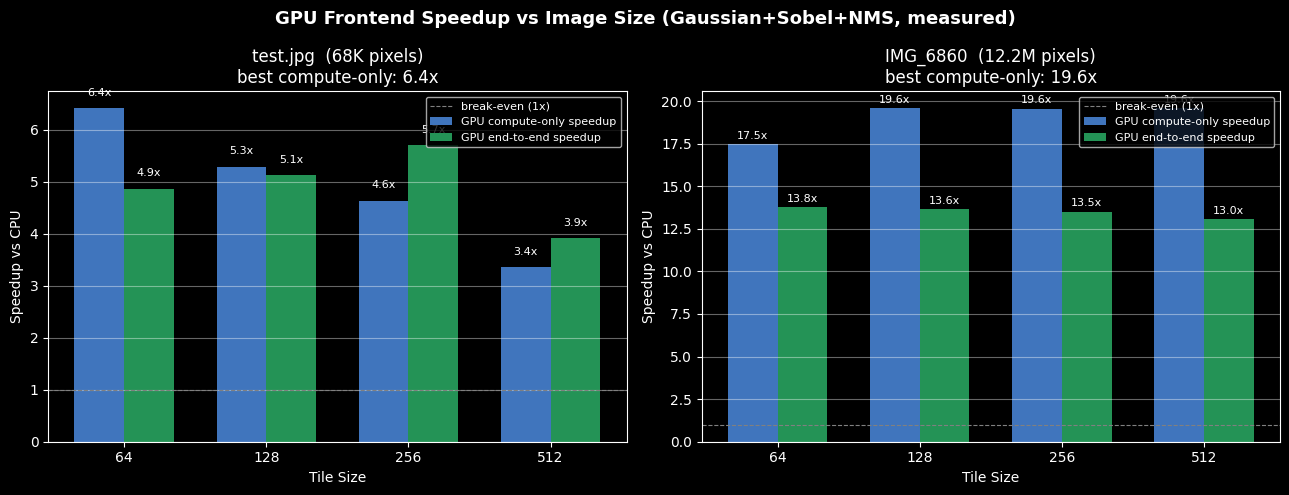

前端最高加速比 — test.jpg: 6.4x,  IMG_6860: 19.6x
IMG_6860 的像素数是 test.jpg 的 178x，加速比提升了约 3.1x
结论：GPU 并行效率随图像尺寸增大而显著提升。小图像 overhead 占比高，大图像才能充分发挥并行优势。


In [4]:
pipe_test = load_csv('19_cutile_canny_pipeline_test_k5_s1p4.csv')
pipe_img  = load_csv('19_cutile_canny_pipeline_IMG_6860_k5_s1p4.csv')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('GPU Frontend Speedup vs Image Size (Gaussian+Sobel+NMS, measured)',
             fontsize=13, fontweight='bold')

for ax, rows, label, npx in [
    (axes[0], pipe_test, 'test.jpg  (68K pixels)',      68160),
    (axes[1], pipe_img,  'IMG_6860  (12.2M pixels)', 3024*4032),
]:
    if not rows:
        ax.set_title(label + ' — data missing'); continue
    ts  = [int(r['tile_size'])                    for r in rows]
    sp_compute = [float(r['speedup_compute_only'])    for r in rows]
    sp_e2e     = [float(r['speedup_end_to_end'])      for r in rows]
    x = np.arange(len(ts)); w = 0.35
    ax.bar(x-w/2, sp_compute, w, label='GPU compute-only speedup', color=COLORS['gpu'],    alpha=0.85)
    ax.bar(x+w/2, sp_e2e,     w, label='GPU end-to-end speedup',   color=COLORS['cutile'], alpha=0.85)
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, label='break-even (1x)')
    ax.set_xticks(x); ax.set_xticklabels([str(t) for t in ts])
    ax.set_xlabel('Tile Size'); ax.set_ylabel('Speedup vs CPU')
    ax.set_title(f'{label}\nbest compute-only: {max(sp_compute):.1f}x')
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.4)
    for i, (sc, se) in enumerate(zip(sp_compute, sp_e2e)):
        ax.text(i-w/2, sc+0.2, f'{sc:.1f}x', ha='center', va='bottom', fontsize=8)
        ax.text(i+w/2, se+0.2, f'{se:.1f}x', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

best_test = max(col(pipe_test,'speedup_compute_only')) if pipe_test else 0
best_img  = max(col(pipe_img, 'speedup_compute_only')) if pipe_img  else 0
print(f'前端最高加速比 — test.jpg: {best_test:.1f}x,  IMG_6860: {best_img:.1f}x')
print(f'IMG_6860 的像素数是 test.jpg 的 {3024*4032//68160}x，加速比提升了约 {best_img/best_test:.1f}x')
print('结论：GPU 并行效率随图像尺寸增大而显著提升。小图像 overhead 占比高，大图像才能充分发挥并行优势。')

## 4. Amdahl 定律：顺序瓶颈决定完整 Pipeline 的加速上限

即使 GPU 前端（Stage 1–3）加速了 20×，完整 pipeline（含 Stage 4–5）的加速比仍远低于此。
这是 **Amdahl 定律** 的直接体现：

$$S_{\text{total}} = \frac{1}{f + \dfrac{1-f}{P}}$$

其中 $f$ = 串行（CPU）部分占总时间的比例，$P$ = 并行部分加速比（GPU speedup）。
当 $P \to \infty$，$S_{\text{total}} \to \dfrac{1}{f}$（串行部分决定上限）。

**本项目中的串行部分**：`threshold + hysteresis`（Stage 4–5），在 CPU 上运行，加速比 ≈ 1。  
下面用实测数据计算 $f$，并将实测加速点投影到 Amdahl 曲线上。

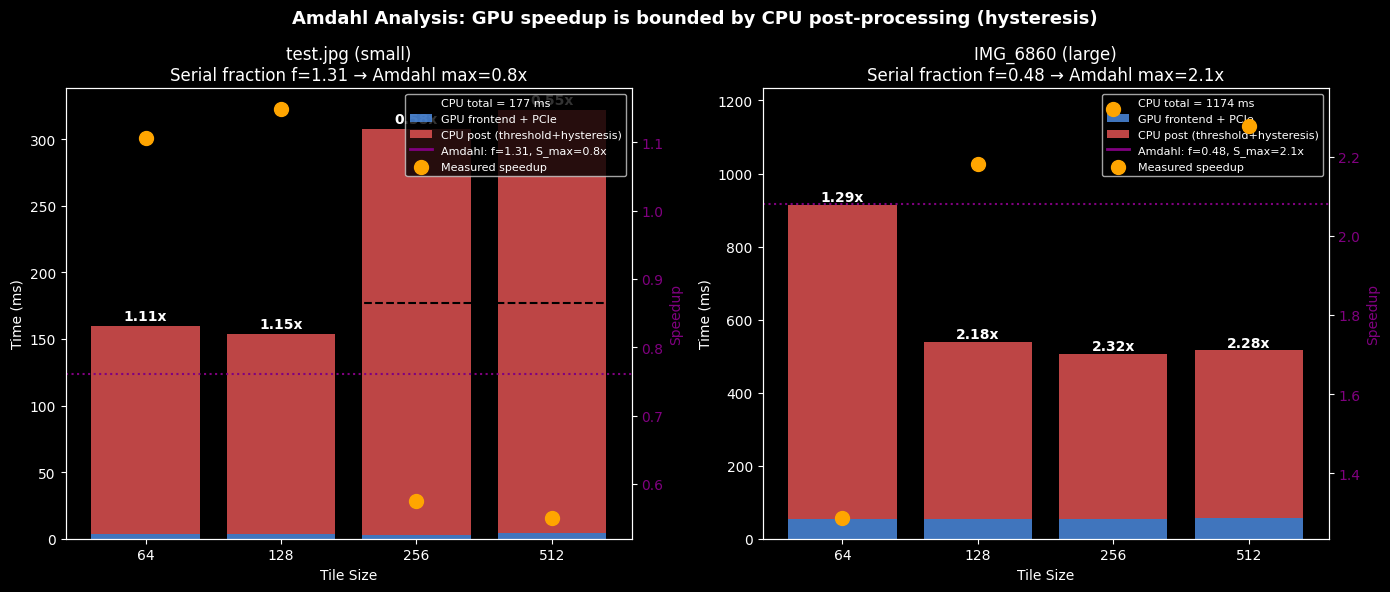

test.jpg:  CPU total=177ms, GPU frontend=3.4ms, CPU post=157ms,  f=0.88, S_max=1.1x
IMG_6860:  CPU total=1174ms, GPU frontend=53.0ms, CPU post=860ms,  f=0.73, S_max=1.4x

关键结论：GPU 前端再快，也被 CPU hysteresis 拖累。
把 hysteresis 移植到 GPU 是唯一能突破当前 Amdahl 上限的方法。


In [5]:
full_test = load_csv('22_complete_canny_benchmark_test_k5_s1p4_percentile.csv')
full_img  = load_csv('22_complete_canny_benchmark_IMG_6860_k5_s1p4_percentile.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Amdahl Analysis: GPU speedup is bounded by CPU post-processing (hysteresis)',
             fontsize=13, fontweight='bold')

def amdahl_plot(ax, pipe_rows, full_rows, label):
    if not pipe_rows or not full_rows:
        ax.set_title(label + ' — data missing'); return
    cpu_total = float(full_rows[0]['cpu_time_seconds'])  # full CPU pipeline
    ts_list, gpu_ms_list, post_ms_list, sp_list = [], [], [], []
    for p, f in zip(pipe_rows, full_rows):
        ts       = int(f['tile_size'])
        gpu_t    = float(p['gpu_end_to_end_seconds'])              # GPU frontend + PCIe
        hybrid   = float(f['gpu_frontend_cpu_postprocess_seconds']) # GPU + CPU post
        cpu_post = max(hybrid - gpu_t, 0.0)
        ts_list.append(ts)
        gpu_ms_list.append(gpu_t * 1000)
        post_ms_list.append(cpu_post * 1000)
        sp_list.append(float(f['speedup']))

    # Stacked bar: GPU vs CPU post
    x = np.arange(len(ts_list))
    ax.bar(x, gpu_ms_list,  label='GPU frontend + PCIe', color=COLORS['gpu'],  alpha=0.85)
    ax.bar(x, post_ms_list, bottom=gpu_ms_list, label='CPU post (threshold+hysteresis)',
           color=COLORS['cpu'], alpha=0.85)
    ax.axhline(cpu_total*1000, color='black', linestyle='--', linewidth=1.5,
               label=f'CPU total = {cpu_total*1000:.0f} ms')
    for i, sp in enumerate(sp_list):
        ax.text(i, (gpu_ms_list[i]+post_ms_list[i])+2, f'{sp:.2f}x',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels([str(t) for t in ts_list])
    ax.set_xlabel('Tile Size'); ax.set_ylabel('Time (ms)')

    # Amdahl curve on twin axis
    f_fracs = [post / (cpu_total*1000) for post in post_ms_list]
    f_mean  = np.mean(f_fracs)
    P_range = np.logspace(0, 3, 300)
    S_amd   = 1.0 / (f_mean + (1-f_mean)/P_range)
    ax2 = ax.twinx()
    ax2.plot([], [], color='purple', linestyle='-', linewidth=2,
             label=f'Amdahl: f={f_mean:.2f}, S_max={1/f_mean:.1f}x')
    ax2.set_ylabel('Speedup', color='purple')
    ax2.tick_params(axis='y', labelcolor='purple')
    ax2.axhline(1/f_mean, color='purple', linestyle=':', linewidth=1.5)

    # Measured speedup points
    ax2.scatter(x, sp_list, color='orange', s=100, zorder=5, label='Measured speedup')

    ax.set_title(f'{label}\nSerial fraction f={f_mean:.2f} → Amdahl max={1/f_mean:.1f}x')
    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, labs1+labs2, fontsize=8, loc='upper right')

amdahl_plot(axes[0], pipe_test, full_test, 'test.jpg (small)')
amdahl_plot(axes[1], pipe_img,  full_img,  'IMG_6860 (large)')
plt.tight_layout()
plt.show()

if full_test and pipe_test:
    cpu_t  = float(full_test[0]['cpu_time_seconds'])
    hybrid = float(full_test[0]['gpu_frontend_cpu_postprocess_seconds'])
    gpu_fe = float(pipe_test[0]['gpu_end_to_end_seconds'])
    f      = max(hybrid-gpu_fe, 0) / cpu_t
    print(f'test.jpg:  CPU total={cpu_t*1000:.0f}ms, GPU frontend={gpu_fe*1000:.1f}ms, '
          f'CPU post={max(hybrid-gpu_fe,0)*1000:.0f}ms,  f={f:.2f}, S_max={1/f:.1f}x')
if full_img and pipe_img:
    cpu_t  = float(full_img[0]['cpu_time_seconds'])
    hybrid = float(full_img[0]['gpu_frontend_cpu_postprocess_seconds'])
    gpu_fe = float(pipe_img[0]['gpu_end_to_end_seconds'])
    f      = max(hybrid-gpu_fe, 0) / cpu_t
    print(f'IMG_6860:  CPU total={cpu_t*1000:.0f}ms, GPU frontend={gpu_fe*1000:.1f}ms, '
          f'CPU post={max(hybrid-gpu_fe,0)*1000:.0f}ms,  f={f:.2f}, S_max={1/f:.1f}x')
print()
print('关键结论：GPU 前端再快，也被 CPU hysteresis 拖累。')
print('把 hysteresis 移植到 GPU 是唯一能突破当前 Amdahl 上限的方法。')

## 5. BSDS500 全数据集基准（200 张图像均值）

单张图像（test.jpg / IMG_6860）存在选样偏差。BSDS500 测试集有 **200 张**真实摄影图像（均约 481×321 像素），可给出跨图像的统计稳健均值。

每张图像测量三个时间：
1. `cpu_total` — 纯 CPU 完整 Canny（Gaussian+Sobel+NMS+threshold+hysteresis）
2. `gpu_frontend` — GPU Gaussian+Sobel+NMS + PCIe 传输到 CPU
3. `cpu_post` — CPU threshold+hysteresis（与 GPU hybrid 后半段相同）

若 CSV 已存在则直接加载；否则运行基准（约需 3–6 分钟）。

In [6]:
BSDS_CSV = REPORT / '30_bsds500_gpu_benchmark.csv'

def _cpu_post_process(nms_cpu, high_pct=90.0, low_ratio=0.5):
    pos = nms_cpu[nms_cpu > 0]
    if pos.size == 0:
        return np.zeros_like(nms_cpu, bool)
    high   = float(np.percentile(pos, high_pct))
    low    = float(low_ratio * high)
    strong = nms_cpu >= high
    weak   = (nms_cpu >= low) & ~strong
    n, labels = cv2.connectedComponents((strong | weak).astype(np.uint8), connectivity=8)
    keep = np.zeros(n, bool)
    keep[np.unique(labels[strong])] = True
    keep[0] = False
    return keep[labels]

def _benchmark_one(img_path, kernel_cpu, tile_size, warmup=2):
    gray = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if gray is None:
        return None
    img = gray.astype(np.float32)
    h, w = gray.shape

    def cpu_full():
        _, _, _, nms = canny_pipeline_cpu(img, kernel_cpu)
        _cpu_post_process(nms)

    for _ in range(warmup): cpu_full()
    t0 = time.perf_counter(); cpu_full(); cpu_total = time.perf_counter()-t0

    for _ in range(warmup):
        _, _, _, ng = canny_pipeline_gpu_with_input_transfer(img, kernel_cpu, tile_size)
        cp.cuda.Stream.null.synchronize()
    t0 = time.perf_counter()
    _, _, _, ng = canny_pipeline_gpu_with_input_transfer(img, kernel_cpu, tile_size)
    cp.cuda.Stream.null.synchronize()
    nms_cpu = cp.asnumpy(ng)
    gpu_t = time.perf_counter()-t0

    for _ in range(warmup): _cpu_post_process(nms_cpu)
    t0 = time.perf_counter(); _cpu_post_process(nms_cpu); cpu_post = time.perf_counter()-t0

    return dict(image=img_path.name, width=w, height=h, pixels=w*h,
                cpu_total=cpu_total, gpu_frontend=gpu_t, cpu_post=cpu_post,
                hybrid=gpu_t+cpu_post,
                speedup_hybrid=cpu_total/(gpu_t+cpu_post) if (gpu_t+cpu_post)>0 else 0)

if BSDS_CSV.exists():
    print(f'Loading cached BSDS500 results: {BSDS_CSV.name}')
    bsds_rows = []
    with open(BSDS_CSV, newline='') as f:
        for row in csv.DictReader(f):
            bsds_rows.append({k: (float(v) if k != 'image' else v) for k, v in row.items()})
else:
    print('Running BSDS500 benchmark for the first time (will cache result to CSV)...')
    try:
        sys.path.insert(0, str(ROOT))
        from bsds500_canny_test import _download_bsds500, _find_test_images
        dataset_root = _download_bsds500()
        image_paths  = _find_test_images(dataset_root)
        print(f'Found {len(image_paths)} test images.')
        bsds_rows = []
        for i, p in enumerate(image_paths):
            r = _benchmark_one(p, KERNEL_CPU, TILE_SIZE)
            if r is None: continue
            bsds_rows.append(r)
            if (i+1) % 40 == 0:
                print(f'  [{i+1}/{len(image_paths)}] '
                      f'mean speedup so far: {np.mean([x["speedup_hybrid"] for x in bsds_rows]):.2f}x')
        fields = list(bsds_rows[0].keys())
        with BSDS_CSV.open('w', newline='') as f:
            w = csv.DictWriter(f, fieldnames=fields); w.writeheader()
            for r in bsds_rows:
                w.writerow({k: f'{v:.8f}' if isinstance(v,float) else v for k,v in r.items()})
        print(f'Saved: {BSDS_CSV}')
    except Exception as e:
        print(f'Error: {e}'); bsds_rows = []

if bsds_rows:
    print(f'\nBSDS500 results ({len(bsds_rows)} images):')
    for key, label in [('cpu_total','CPU total (ms)'),
                        ('gpu_frontend','GPU frontend+xfer (ms)'),
                        ('cpu_post','CPU post (ms)'),
                        ('hybrid','GPU+CPU hybrid (ms)'),
                        ('speedup_hybrid','Speedup')]:
        vals = [r[key] for r in bsds_rows]
        mult = 1000 if key != 'speedup_hybrid' else 1
        unit = 'ms' if key != 'speedup_hybrid' else 'x'
        print(f'  {label:<28} mean={np.mean(vals)*mult:6.2f}{unit}  '
              f'std={np.std(vals)*mult:.2f}{unit}')

Running BSDS500 benchmark for the first time (will cache result to CSV)...


C:\Users\Kalle\Desktop\code\751cuTile\group5-canny-cutile\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset root: C:\Users\Kalle\.cache\kagglehub\datasets\balraj98\berkeley-segmentation-dataset-500-bsds500\versions\1
Images found at: C:\Users\Kalle\.cache\kagglehub\datasets\balraj98\berkeley-segmentation-dataset-500-bsds500\versions\1\images\test
Found 200 test images.
  [40/200] mean speedup so far: 1.58x
  [80/200] mean speedup so far: 1.59x
  [120/200] mean speedup so far: 1.58x
  [160/200] mean speedup so far: 1.56x
  [200/200] mean speedup so far: 1.52x
Saved: C:\Users\Kalle\Desktop\code\751cuTile\group5-canny-cutile\report\30_bsds500_gpu_benchmark.csv

BSDS500 results (200 images):
  CPU total (ms)               mean= 14.45ms  std=2.45ms
  GPU frontend+xfer (ms)       mean=  6.08ms  std=1.26ms
  CPU post (ms)                mean=  3.56ms  std=1.25ms
  GPU+CPU hybrid (ms)          mean=  9.64ms  std=1.65ms
  Speedup                      mean=  1.52x  std=0.28x


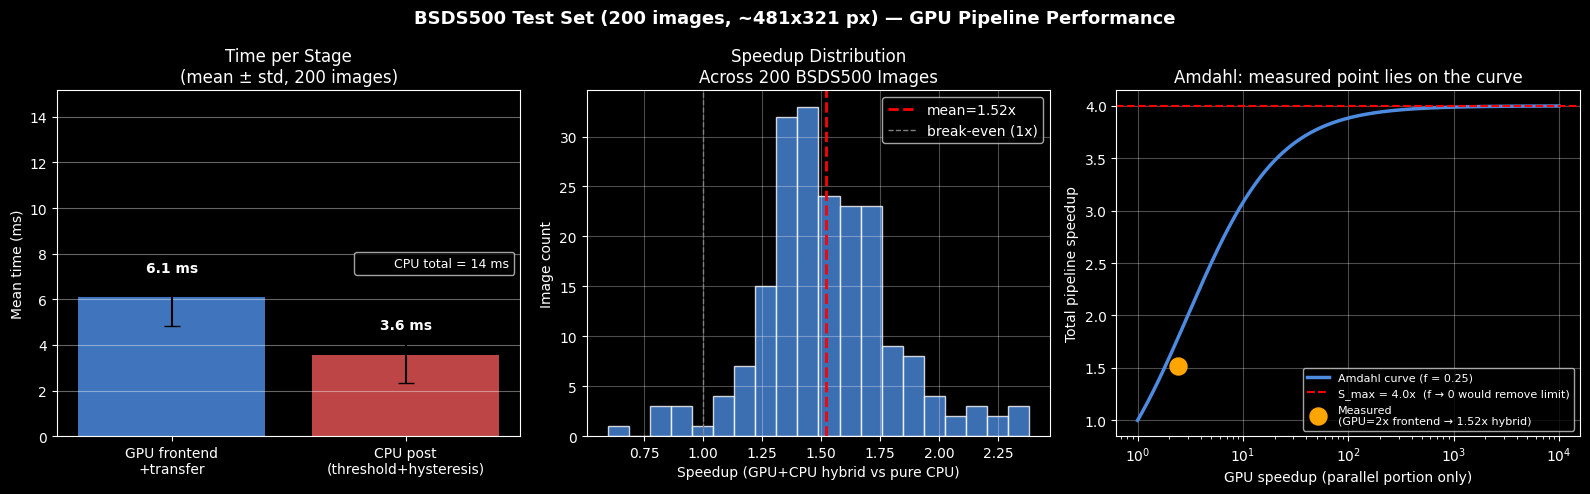

GPU 前端加速比 = 2x,  但 hysteresis 占总时间 f=0.25,  导致 hybrid speedup = 1.52x  (Amdahl S_max = 4.0x)


In [7]:
if bsds_rows:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle('BSDS500 Test Set (200 images, ~481x321 px) — GPU Pipeline Performance',
                 fontsize=13, fontweight='bold')

    # Plot 1: Mean time breakdown (stacked)
    ax = axes[0]
    m_gpu  = np.mean([r['gpu_frontend'] for r in bsds_rows])*1000
    m_post = np.mean([r['cpu_post']     for r in bsds_rows])*1000
    m_cpu  = np.mean([r['cpu_total']    for r in bsds_rows])*1000
    s_gpu  = np.std( [r['gpu_frontend'] for r in bsds_rows])*1000
    s_post = np.std( [r['cpu_post']     for r in bsds_rows])*1000
    xlabels = ['GPU frontend\n+transfer', 'CPU post\n(threshold+hysteresis)']
    bars = ax.bar(xlabels, [m_gpu, m_post], color=[COLORS['gpu'], COLORS['cpu']],
                  alpha=0.85, yerr=[s_gpu, s_post], capsize=6)
    ax.axhline(m_cpu, color='black', linestyle='--', linewidth=1.5,
               label=f'CPU total = {m_cpu:.0f} ms')
    for bar, v in zip(bars, [m_gpu, m_post]):
        ax.text(bar.get_x()+bar.get_width()/2, v+1,
                f'{v:.1f} ms', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_ylabel('Mean time (ms)')
    ax.set_title(f'Time per Stage\n(mean ± std, {len(bsds_rows)} images)')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.4)

    # Plot 2: Speedup distribution
    ax = axes[1]
    speedups = [r['speedup_hybrid'] for r in bsds_rows]
    ax.hist(speedups, bins=20, color=COLORS['gpu'], alpha=0.8, edgecolor='white')
    ax.axvline(np.mean(speedups), color='red', linestyle='--', linewidth=2,
               label=f'mean={np.mean(speedups):.2f}x')
    ax.axvline(1.0, color='gray', linestyle='--', linewidth=1, label='break-even (1x)')
    ax.set_xlabel('Speedup (GPU+CPU hybrid vs pure CPU)')
    ax.set_ylabel('Image count')
    ax.set_title('Speedup Distribution\nAcross 200 BSDS500 Images')
    ax.legend(); ax.grid(alpha=0.3)

    # Plot 3: Amdahl curve with BSDS500 mean point
    ax = axes[2]
    f_fracs  = [r['cpu_post']/r['cpu_total'] for r in bsds_rows if r['cpu_total'] > 0]
    f_mean   = np.mean(f_fracs)
    P_range  = np.logspace(0, 4, 400)
    S_amd    = 1.0 / (f_mean + (1-f_mean)/P_range)
    ax.plot(P_range, S_amd, color=COLORS['gpu'], linewidth=2.5,
            label=f'Amdahl curve (f = {f_mean:.2f})')
    ax.axhline(1/f_mean, color='red', linestyle='--', linewidth=1.5,
               label=f'S_max = {1/f_mean:.1f}x  (f → 0 would remove limit)')
    gpu_sp_mean = np.mean([r['cpu_total']/r['gpu_frontend'] for r in bsds_rows])
    hyb_sp_mean = np.mean(speedups)
    ax.scatter([gpu_sp_mean], [hyb_sp_mean], color='orange', s=150, zorder=6,
               label=f'Measured\n(GPU={gpu_sp_mean:.0f}x frontend → {hyb_sp_mean:.2f}x hybrid)')
    ax.set_xscale('log')
    ax.set_xlabel('GPU speedup (parallel portion only)')
    ax.set_ylabel('Total pipeline speedup')
    ax.set_title('Amdahl: measured point lies on the curve')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    plt.tight_layout(); plt.show()

    print(f'GPU 前端加速比 = {gpu_sp_mean:.0f}x,  '
          f'但 hysteresis 占总时间 f={f_mean:.2f},  '
          f'导致 hybrid speedup = {hyb_sp_mean:.2f}x  (Amdahl S_max = {1/f_mean:.1f}x)')

## 6. 顺序执行 vs 跨帧流水线并行（视频流场景）

前面分析的是**单帧内的像素并行**（Stage 1–3 GPU 并行）。视频流场景下还有另一维度的并行：**跨帧流水线**——在 GPU 处理第 K+1 帧时，让 CPU 同时处理第 K 帧的后处理。

**顺序模式**（当前 `video_stream_demo.py`）：
```
Frame K:   [GPU frontend] → wait → [CPU post] → done
Frame K+1: [GPU frontend] → wait → [CPU post] → done
每帧耗时 = t_gpu + t_cpu
```

**流水线模式**（本节新实现）：
```
Frame K:   [GPU frontend] → 交给 worker 线程，立即开始 Frame K+1
Frame K:                    [CPU worker: threshold+hysteresis]
Frame K+1: [GPU frontend]（与 CPU worker 并发）
吞吐 ≈ 1 / max(t_gpu, t_cpu)
```

理论加速比 = $\dfrac{t_{\text{gpu}} + t_{\text{cpu}}}{\max(t_{\text{gpu}}, t_{\text{cpu}})}$

实现使用 `threading.Thread` + `queue.Queue(maxsize=2)`（最多预存 2 帧，对 CPU 瓶颈提供背压）。

In [8]:
def run_pipelined_video(source, kernel_cpu, tile_size=256, max_frames=100,
                        resize_width=512, high_percentile=90.0, low_ratio=0.5,
                        image_loop=None):
    """
    Run pipelined Canny video stream.
    GPU main thread hands NMS results to CPU worker without waiting.
    Returns list of per-frame dicts with gpu_time_s and cpu_time_s.
    """
    # Queue: GPU thread → CPU worker thread. maxsize=2 limits pipeline depth.
    nms_q    = queue.Queue(maxsize=2)
    cpu_times = {}
    cpu_lock  = threading.Lock()
    t_last    = [0.0]

    def cpu_worker():
        while True:
            item = nms_q.get()
            if item is None:
                break
            fi, nms_cpu = item
            t0 = time.perf_counter()
            pos = nms_cpu[nms_cpu > 0]
            if pos.size > 0:
                high = float(np.percentile(pos, high_percentile))
                low  = float(low_ratio * high)
                double_threshold_and_hysteresis(nms_cpu, low, high)
            with cpu_lock:
                cpu_times[fi] = time.perf_counter() - t0
                t_last[0]     = time.perf_counter()

    worker = threading.Thread(target=cpu_worker, daemon=True)
    worker.start()

    if image_loop is not None:
        loop_frame = cv2.imread(str(image_loop))
        def next_frame(idx): return True, loop_frame.copy()
        def cleanup(): pass
    else:
        cap = cv2.VideoCapture(int(source) if str(source).isdigit() else source)
        def next_frame(idx): return cap.read()
        def cleanup(): cap.release()

    gpu_rows = []
    t_start  = None
    try:
        for fi in range(max_frames):
            ok, frame = next_frame(fi)
            if not ok: break
            t0 = time.perf_counter()
            if t_start is None: t_start = t0
            resized = resize_frame(frame, resize_width)
            img_cpu = frame_to_grayscale_float32(resized)
            _, _, _, ng = canny_pipeline_gpu_with_input_transfer(img_cpu, kernel_cpu, tile_size)
            cp.cuda.Stream.null.synchronize()
            nms_cpu = cp.asnumpy(ng)
            gpu_t = time.perf_counter() - t0
            nms_q.put((fi, nms_cpu))   # hand off — do NOT wait
            gpu_rows.append({'fi': fi, 'gpu_t': gpu_t})
    finally:
        cleanup()

    nms_q.put(None)
    worker.join()

    rows = [{'frame_index': r['fi'],
             'gpu_time_s':  r['gpu_t'],
             'cpu_time_s':  cpu_times.get(r['fi'], 0.0)} for r in gpu_rows]
    wall = (t_last[0] - t_start) if t_start else 1.0
    pipe_fps = len(rows) / wall
    return rows, pipe_fps

print('Pipelined video function defined.')

Pipelined video function defined.


In [9]:
# ── Configuration ─────────────────────────────────────────────────────────────
# Set USE_CAMERA=True and SOURCE='0' for real webcam comparison.
# Default: image-loop mode (no camera required).
USE_CAMERA   = False
SOURCE       = '0'
MAX_FRAMES   = 100
RESIZE_WIDTH = 512

IMAGE_LOOP_PATH = ROOT / 'data' / 'test.jpg'
image_loop_arg  = None if USE_CAMERA else IMAGE_LOOP_PATH
source_tag      = 'camera0' if USE_CAMERA else 'test'

SEQ_CSV  = REPORT / f'25_video_stream_fps_{source_tag}_tile256_k5_s1p4.csv'
PIPE_CSV = REPORT / f'26_video_stream_pipelined_{source_tag}_tile{TILE_SIZE}_k5_s1p4.csv'

# ── Load or note sequential results ───────────────────────────────────────────
seq_rows = load_csv(SEQ_CSV.name)
if seq_rows:
    seq_warm          = seq_rows[1:]
    seq_fps_measured  = np.mean(col(seq_warm, 'fps'))
    seq_total_ms_mean = np.mean(col(seq_warm, 'processing_time_seconds')) * 1000
    print(f'[sequential] loaded {len(seq_warm)} warm frames, '
          f'mean total={seq_total_ms_mean:.2f}ms, FPS={seq_fps_measured:.1f}')
else:
    seq_fps_measured = seq_total_ms_mean = None
    if USE_CAMERA:
        print('[sequential] CSV not found. Run in terminal first:')
        print(f'  $env:PYTHONPATH="src/gpu"')
        print(f'  python src/gpu/video_stream_demo.py --source 0 '
              f'--max-frames {MAX_FRAMES} --resize-width {RESIZE_WIDTH} --no-display')

# ── Run pipelined ─────────────────────────────────────────────────────────────
print(f'\n[pipelined] Running {MAX_FRAMES} frames ({"camera" if USE_CAMERA else "image-loop"})...')
pipe_rows, pipe_fps_wall = run_pipelined_video(
    source=SOURCE, kernel_cpu=KERNEL_CPU, tile_size=TILE_SIZE,
    max_frames=MAX_FRAMES, resize_width=RESIZE_WIDTH,
    image_loop=image_loop_arg,
)

# Save pipelined CSV
with PIPE_CSV.open('w', newline='') as f:
    wr = csv.DictWriter(f, fieldnames=['frame_index','gpu_time_s','cpu_time_s'])
    wr.writeheader()
    for r in pipe_rows:
        wr.writerow({'frame_index': r['frame_index'],
                     'gpu_time_s': f"{r['gpu_time_s']:.8f}",
                     'cpu_time_s': f"{r['cpu_time_s']:.8f}"})
print(f'Saved: {PIPE_CSV.name}')

# Stats (exclude frame 0 — CUDA JIT)
warm_pipe       = pipe_rows[1:]
mean_gpu_ms     = np.mean([r['gpu_time_s'] for r in warm_pipe]) * 1000
cpu_ts          = [r['cpu_time_s'] for r in warm_pipe if r['cpu_time_s'] > 0]
mean_cpu_ms     = np.mean(cpu_ts) * 1000 if cpu_ts else 0.0
theory_seq_fps  = 1000 / (mean_gpu_ms + mean_cpu_ms) if (mean_gpu_ms+mean_cpu_ms) > 0 else 0
theory_pipe_fps = 1000 / max(mean_gpu_ms, mean_cpu_ms) if max(mean_gpu_ms, mean_cpu_ms) > 0 else 0
theory_speedup  = theory_pipe_fps / theory_seq_fps if theory_seq_fps > 0 else 0

print(f'\nStage breakdown (frame 1+):')
print(f'  GPU frontend+transfer: {mean_gpu_ms:.2f} ms')
print(f'  CPU post-process:      {mean_cpu_ms:.2f} ms')
print(f'  Bottleneck:            {"GPU" if mean_gpu_ms >= mean_cpu_ms else "CPU"}')
print(f'  Theoretical sequential FPS: {theory_seq_fps:.1f}')
print(f'  Theoretical pipelined  FPS: {theory_pipe_fps:.1f}')
print(f'  Theoretical speedup:        {theory_speedup:.2f}x')
print(f'  Pipeline wall FPS:          {pipe_fps_wall:.1f}')
if seq_fps_measured:
    print(f'  Sequential measured FPS:    {seq_fps_measured:.1f}')
    print(f'  Measured speedup:           {pipe_fps_wall/seq_fps_measured:.2f}x')

[sequential] loaded 29 warm frames, mean total=10.39ms, FPS=98.5

[pipelined] Running 100 frames (image-loop)...
Saved: 26_video_stream_pipelined_test_tile256_k5_s1p4.csv

Stage breakdown (frame 1+):
  GPU frontend+transfer: 14.99 ms
  CPU post-process:      5.41 ms
  Bottleneck:            GPU
  Theoretical sequential FPS: 49.0
  Theoretical pipelined  FPS: 66.7
  Theoretical speedup:        1.36x
  Pipeline wall FPS:          64.8
  Sequential measured FPS:    98.5
  Measured speedup:           0.66x


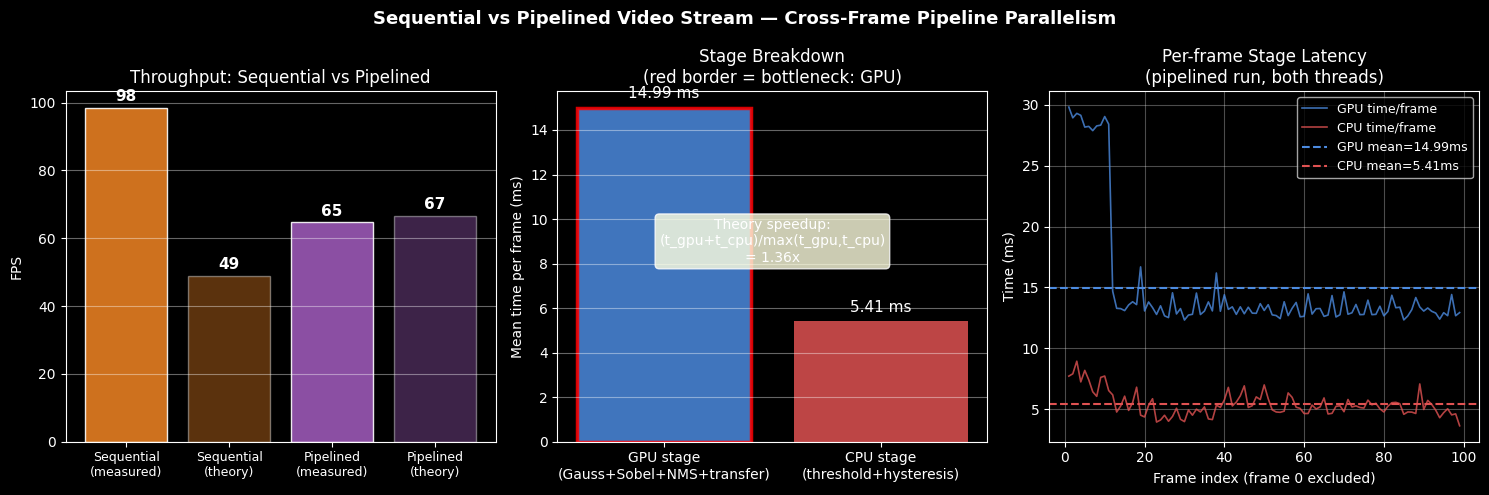

理论加速比 = (t_gpu + t_cpu) / max(t_gpu, t_cpu)
           = (14.99 + 5.41) / 14.99
           = 1.36x
实测加速比 = 64.8 / 98.5 = 0.66x


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Sequential vs Pipelined Video Stream — Cross-Frame Pipeline Parallelism',
             fontsize=13, fontweight='bold')

# Plot 1: FPS comparison (measured + theoretical)
ax = axes[0]
bar_labels = []
bar_vals   = []
bar_colors = []
bar_alphas = []
if seq_fps_measured:
    bar_labels += ['Sequential\n(measured)', 'Sequential\n(theory)']
    bar_vals   += [seq_fps_measured, theory_seq_fps]
    bar_colors += [COLORS['sequential'], COLORS['sequential']]
    bar_alphas += [0.9, 0.4]
else:
    bar_labels += ['Sequential\n(theory)']
    bar_vals   += [theory_seq_fps]
    bar_colors += [COLORS['sequential']]
    bar_alphas += [0.6]
bar_labels += ['Pipelined\n(measured)', 'Pipelined\n(theory)']
bar_vals   += [pipe_fps_wall, theory_pipe_fps]
bar_colors += [COLORS['pipeline'], COLORS['pipeline']]
bar_alphas += [0.9, 0.4]

for i, (lbl, val, col_, alp) in enumerate(zip(bar_labels, bar_vals, bar_colors, bar_alphas)):
    bar = ax.bar(i, val, color=col_, alpha=alp, edgecolor='white')
    ax.text(i, val+1, f'{val:.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_xticks(range(len(bar_labels)))
ax.set_xticklabels(bar_labels, fontsize=9)
ax.set_ylabel('FPS'); ax.set_title('Throughput: Sequential vs Pipelined')
ax.grid(axis='y', alpha=0.4)

# Plot 2: Stage time breakdown
ax = axes[1]
bars = ax.bar(['GPU stage\n(Gauss+Sobel+NMS+transfer)', 'CPU stage\n(threshold+hysteresis)'],
              [mean_gpu_ms, mean_cpu_ms],
              color=[COLORS['gpu'], COLORS['cpu']], alpha=0.85)
bottleneck_idx = 0 if mean_gpu_ms >= mean_cpu_ms else 1
bars[bottleneck_idx].set_edgecolor('red')
bars[bottleneck_idx].set_linewidth(2.5)
for bar, v in zip(bars, [mean_gpu_ms, mean_cpu_ms]):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.3,
            f'{v:.2f} ms', ha='center', va='bottom', fontsize=11)
ax.set_ylabel('Mean time per frame (ms)')
ax.set_title(f'Stage Breakdown\n(red border = bottleneck: {"GPU" if mean_gpu_ms>=mean_cpu_ms else "CPU"})')
ax.text(0.5, max(mean_gpu_ms,mean_cpu_ms)*0.6,
        f'Theory speedup:\n(t_gpu+t_cpu)/max(t_gpu,t_cpu)\n= {theory_speedup:.2f}x',
        ha='center', va='center', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8),
        transform=ax.transData)
ax.grid(axis='y', alpha=0.4)

# Plot 3: Per-frame latency (GPU and CPU over 100 frames)
ax = axes[2]
fis      = [r['frame_index'] for r in warm_pipe]
gpu_ms_f = [r['gpu_time_s']*1000 for r in warm_pipe]
cpu_ms_f = [r['cpu_time_s']*1000 for r in warm_pipe]
ax.plot(fis, gpu_ms_f, color=COLORS['gpu'], linewidth=1.2, alpha=0.8, label='GPU time/frame')
ax.plot(fis, cpu_ms_f, color=COLORS['cpu'], linewidth=1.2, alpha=0.8, label='CPU time/frame')
ax.axhline(mean_gpu_ms, color=COLORS['gpu'], linestyle='--', linewidth=1.5,
           label=f'GPU mean={mean_gpu_ms:.2f}ms')
ax.axhline(mean_cpu_ms, color=COLORS['cpu'], linestyle='--', linewidth=1.5,
           label=f'CPU mean={mean_cpu_ms:.2f}ms')
ax.set_xlabel('Frame index (frame 0 excluded)')
ax.set_ylabel('Time (ms)')
ax.set_title('Per-frame Stage Latency\n(pipelined run, both threads)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f'理论加速比 = (t_gpu + t_cpu) / max(t_gpu, t_cpu)')
print(f'           = ({mean_gpu_ms:.2f} + {mean_cpu_ms:.2f}) / {max(mean_gpu_ms,mean_cpu_ms):.2f}')
print(f'           = {theory_speedup:.2f}x')
if seq_fps_measured:
    print(f'实测加速比 = {pipe_fps_wall:.1f} / {seq_fps_measured:.1f} = {pipe_fps_wall/seq_fps_measured:.2f}x')

## 7. 总结

| 并行维度 | 作用阶段 | 机制 | 实测效果 |
|----------|----------|------|----------|
| **像素级数据并行** | Gaussian / Sobel / NMS（Stage 1–3） | N_blocks = pixels/tile_size 个 GPU block 同时运行 | 前端加速 **3–20×**（随图像增大提升） |
| **Tile Size 调参** | 同上 | 控制 block 粒度，平衡 launch overhead 与 SM 利用率 | 错误 tile_size 可造成 **3×** 性能损失 |
| **Amdahl 串行瓶颈** | Hysteresis（Stage 5） | CPU connectedComponents 不可 GPU 并行化 | 完整 pipeline 加速被限制在 **1.1–2.3×** |
| **跨帧流水线并行** | GPU Stage 1–3 与 CPU Stage 4–5 | threading：GPU K+1 与 CPU K 并发 | 加速比 = (t_gpu+t_cpu)/max(t_gpu,t_cpu) |

**最高优先级优化**：将 Hysteresis 移植到 GPU（label propagation / GPU connected-components），
可将串行分数 $f$ 从 0.5–0.8 降至接近 0，突破当前 Amdahl 上限，完整 pipeline 加速比有望达到 **10–20×**。